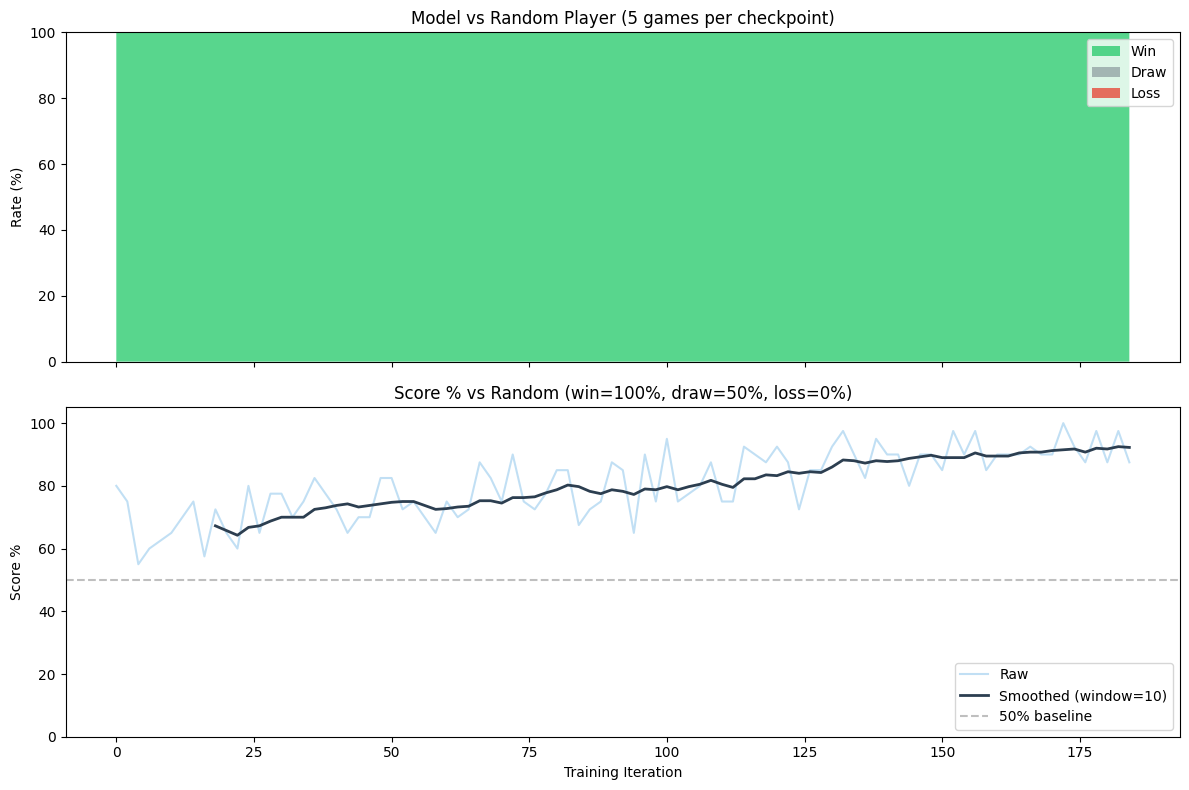

In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np

with open("/home/kuba/Documents/classes/explainable-grandmaster/results/sgd_gate_run/eval_vs_random_best.json") as f:
    data = json.load(f)

iterations = [d["iteration"] for d in data]
win_rate = [d["wins"] / 5 * 100 for d in data]
draw_rate = [d["draws"] / 5 * 100 for d in data]
loss_rate = [d["losses"] / 5 * 100 for d in data]
score_pct = [d["score_pct"] for d in data]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: stacked area of win/draw/loss
ax1.stackplot(iterations, win_rate, draw_rate, loss_rate,
              labels=["Win", "Draw", "Loss"],
              colors=["#2ecc71", "#95a5a6", "#e74c3c"], alpha=0.8)
ax1.set_ylabel("Rate (%)")
ax1.set_title("Model vs Random Player (5 games per checkpoint)")
ax1.legend(loc="upper right")
ax1.set_ylim(0, 100)

# Bottom: score % with smoothing
window = 10
score_smooth = np.convolve(score_pct, np.ones(window)/window, mode="valid")
iter_smooth = iterations[window-1:]
ax2.plot(iterations, score_pct, alpha=0.3, color="#3498db", label="Raw")
ax2.plot(iter_smooth, score_smooth, color="#2c3e50", linewidth=2, label=f"Smoothed (window={window})")
ax2.axhline(y=50, color="gray", linestyle="--", alpha=0.5, label="50% baseline")
ax2.set_xlabel("Training Iteration")
ax2.set_ylabel("Score %")
ax2.set_title("Score % vs Random (win=100%, draw=50%, loss=0%)")
ax2.legend(loc="lower right")
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()